In [5]:
import math
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
def f(x):
    return x**2 + 2*x + 1

In [4]:
f(3)

16

In [7]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys

array([16.    , 14.0625, 12.25  , 10.5625,  9.    ,  7.5625,  6.25  ,
        5.0625,  4.    ,  3.0625,  2.25  ,  1.5625,  1.    ,  0.5625,
        0.25  ,  0.0625,  0.    ,  0.0625,  0.25  ,  0.5625,  1.    ,
        1.5625,  2.25  ,  3.0625,  4.    ,  5.0625,  6.25  ,  7.5625,
        9.    , 10.5625, 12.25  , 14.0625, 16.    , 18.0625, 20.25  ,
       22.5625, 25.    , 27.5625, 30.25  , 33.0625])

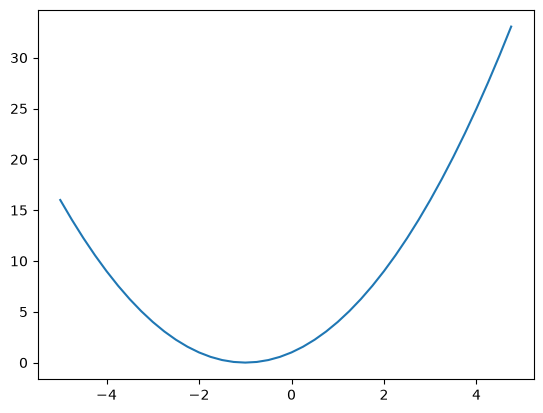

In [9]:
plt.plot(xs,ys)

In [10]:
#derivatives
#slope = lim h->0 (f(x+h) - f(x))/h
x=4
h=0.0001
y = f(x)
y2 = f(x+h)
m = (f(x+h)-f(x))/h
print(y,y2, m)

25 25.00100001 10.000099999984968


In [30]:
class Value:

    def __init__(self, data, _children=(), _op=''):
        self.data=data
        self._prev=set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), "+")

    def __mul__(self, other):
        return Value(self.data*other.data, (self, other), "*")
     


In [36]:
a = Value(22.0)
b = Value(10.0)
c= Value(20.0)
a+b
a*b
d=a*b+c
d._prev

{Value(data=20.0), Value(data=220.0)}

In [42]:
from graphviz import Digraph

def trace(root):
    nodes , edges= set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={"rankdir":"LR"})
    nodes, edges =trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{data %.4f}" % (n.data, ),shape='record')
        if n._op:
            dot.node(name=uid+n._op, label=n._op)
            dot.edge(uid+n._op, uid)
            
    for n1,n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+n2._op)
    return dot


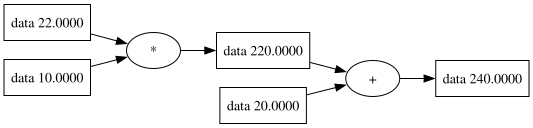

In [44]:
draw_dot(d)